In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from scipy.stats import theilslopes
import matplotlib.pyplot as plt

In [2]:
sample_aint_data = '/g/data/rq0/admin/aint/66/2014/66_20141127_aint.csv'
df = pd.read_csv(sample_aint_data, parse_dates=['time'])

In [3]:
def calculate_theil_sen_parameters(df, minimum_cells = 3):
    """
    Calculate Theil-Sen slope and constants (u, v, x0, y0, t0) for each track.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with columns: 
        - uid: track identification number
        - time: datetime object
        - x: centroid x location (km)
        - y: centroid y location (km)
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame with columns: track_id, u, v, x0, y0, t0
        where:
        - u: velocity in x-direction (km/s)
        - v: velocity in y-direction (km/s)
        - x0, y0: initial position (km)
        - t0: initial time (datetime)
    """
    
    results = []
    
    # Group by track_id
    for track_id, track_data in df.groupby('track_id'):
        # Sort by timestamp to ensure chronological order
        track_data = track_data.sort_values('timestamp')
        if len(track_data) < minimum_cells:
            # Store results
            results.append({
                'track_id': track_id,
                'u': None,  # km/s
                'v': None,  # km/s
                'x0': None, # km
                'y0': None, # km
                't0': None  # datetime
                })
            continue
        
        # Get reference point (first cell in track)
        t0 = track_data['timestamp'].iloc[0] 
        # Convert timestamps to seconds since t0
        time_seconds = (track_data['timestamp'] - t0).dt.total_seconds().values
        
        # Get x and y positions
        x_positions = track_data['lon'].values
        y_positions = track_data['lat'].values

        # Calculate Theil-Sen slopes
        # theilslopes returns: (slope, intercept, low_slope, high_slope)
        u_slope, _, _, _ = theilslopes(x_positions, time_seconds)
        v_slope, _, _, _ = theilslopes(y_positions, time_seconds)

        # Calculate x0 and y0 as median values
        x0 = np.median(x_positions - u_slope * time_seconds)
        y0 = np.median(y_positions - v_slope * time_seconds)

        # Store results
        results.append({
            'track_id': track_id,
            'u': u_slope,  # km/s
            'v': v_slope,  # km/s
            'x0': x0,      # km
            'y0': y0,      # km
            't0': t0       # datetime
        })
    
    return pd.DataFrame(results)

def calculate_distance_to_track(x, y, t, track_params, t0_seconds):
    """
    Calculate perpendicular distance from a point to a track using Eq. (3).
    
    Distance = sqrt((x - x0 - u*(t - t0))^2 + (y - y0 - v*(t - t0))^2)
    
    Parameters:
    -----------
    x, y : float
        Cell position (km)
    t : float
        Time in seconds since reference
    track_params : dict-like
        Track parameters (u, v, x0, y0, t0)
    t0_seconds : float
        Reference time t0 in seconds since some epoch
    
    Returns:
    --------
    float
        Perpendicular distance to track (km)
    """
    dt = t - t0_seconds
    x_expected = track_params['x0'] + track_params['u'] * dt
    y_expected = track_params['y0'] + track_params['v'] * dt
    
    distance = np.sqrt((x - x_expected)**2 + (y - y_expected)**2)
    return distance

def compute_bounding_box(params_dict, track_df, spatial_buffer=0.1, temporal_buffer=600):
    """
    Compute bounding box for a track with added spatial and temporal buffers.
    
    Parameters:
    -----------
    track_df : pandas.DataFrame
        DataFrame containing the track's cell data with columns 'lon', 'lat', 'timestamp'
    spatial_buffer : float
        Buffer to add to spatial dimensions (deg)
    temporal_buffer : float
        Buffer to add to temporal dimension (seconds)
    
    Returns:
    --------
    dict
        Bounding box with keys: x_min, x_max, y_min, y_max, t_min, t_max
    """
    # Pre-compute bounding boxes for all tracks
    track_bboxes = {}
    for track_id in params_dict.keys():
        #skip short tracks with no fits
        if pd.isna(params_dict[track_id]['t0']):
            continue
        track_data = track_df[track_df['track_id'] == track_id]
        track_bboxes[track_id] = {
            'x_min': track_data['lon'].min() - spatial_buffer,
            'x_max': track_data['lon'].max() + spatial_buffer,
            'y_min': track_data['lat'].min() - spatial_buffer,
            'y_max': track_data['lat'].max() + spatial_buffer,
            't_min': track_data['timestamp'].min() - pd.Timedelta(seconds=temporal_buffer),
            't_max': track_data['timestamp'].max() + pd.Timedelta(seconds=temporal_buffer)
        }

    return track_bboxes

def reassign_cells_to_nearest_tracks(df, parameters, distance_threshold=0.1, 
                                     spatial_buffer=0.1, temporal_buffer=600):
    """
    Reassign storm cells to their nearest track if closer than threshold.
    Implements Step 3 of the methodology with optimizations for large datasets.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Original DataFrame with track data
    parameters : pandas.DataFrame
        Track parameters from calculate_theil_sen_parameters
    distance_threshold : float
        Maximum distance (degrees) for reassignment (D parameter)
    spatial_buffer : float
        Spatial buffer for bounding box (degrees)
    temporal_buffer : float
        Temporal buffer for bounding box (seconds)
    
    Returns:
    --------
    pandas.DataFrame
        Updated DataFrame with potentially reassigned track_ids
    int
        Number of cells reassigned
    """
    # Create a copy to avoid modifying original
    df_updated = df.copy()
    
    # Create a reference time epoch for calculations
    time_epoch = df['timestamp'].min()
    df_updated['t_seconds'] = (df_updated['timestamp'] - time_epoch).dt.total_seconds()

    # Convert parameters to dict for faster lookup
    params_dict = parameters.set_index('track_id').to_dict('index')
    # Pre-compute t0 in seconds for all tracks
    for track_id in params_dict.keys():
        params_dict[track_id]['t0_seconds'] = (params_dict[track_id]['t0'] - time_epoch).total_seconds()

    # Pre-compute bounding boxes for all tracks
    track_bboxes = compute_bounding_box(params_dict, df_updated, spatial_buffer=10.0, temporal_buffer=600)
    
    
    # Track reassignments
    reassignments = 0
    new_track_ids = df_updated['track_id'].values.copy()
    filter_record = df_updated['filter'].values.copy()

    for idx in range(len(df_updated)):
        cell = df_updated.iloc[idx]
        cell_x = cell['lon']
        cell_y = cell['lat']
        cell_t = cell['timestamp']
        cell_t_seconds = cell['t_seconds']
        current_track = cell['track_id']
        
        nearest_track = None
        nearest_distance = float('inf')
        
        # Quick bounding box pre-filter
        candidate_tracks = []
        for track_id, bbox in track_bboxes.items():
            # Fast bbox check
            if (bbox['x_min'] <= cell_x <= bbox['x_max'] and
                bbox['y_min'] <= cell_y <= bbox['y_max'] and
                bbox['t_min'] <= cell_t <= bbox['t_max']):
                candidate_tracks.append(track_id)
        
        # If no candidates within bbox, skip
        if not candidate_tracks:
            continue
        
        # Vectorized distance calculation for candidate tracks
        for track_id in candidate_tracks:
            track_params = params_dict[track_id]
            
            # Calculate distance using vectorized operations
            dt = cell_t_seconds - track_params['t0_seconds']
            x_predict = track_params['x0'] + track_params['u'] * dt
            y_predict = track_params['y0'] + track_params['v'] * dt
            distance = np.sqrt((cell_x - x_predict)**2 + (cell_y - y_predict)**2)
            
            if distance < nearest_distance:
                nearest_distance = distance
                nearest_track = track_id
        
        # Reassign if conditions are met
        if (nearest_track is not None and 
            nearest_track != current_track and 
            nearest_distance < distance_threshold):
            # Update in the dataframe's track index
            new_track_ids[idx] = nearest_track
            filter_record[idx] = 1 # Mark as reassigned in filter column
            reassignments += 1
    
    # Apply reassignments
    df_updated['track_id'] = new_track_ids
    df_updated['filter'] = filter_record
    df_updated.drop('t_seconds', axis=1, inplace=True)
    
    return df_updated, reassignments

def merge_tracks(df, parameters, distance_threshold=0.2, time_threshold=600, time_overlap_threshold=960):
    """
    Merge tracks after reassignment.
    Implements the final step of Step 3.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with track data (after reassignment)
    parameters : pandas.DataFrame
        Track parameters from calculate_theil_sen_parameters
    distance_threshold : float
        Maximum distance (degrees) for merging trajectories (D parameter)
    time_overlap_threshold : float
        Maximum time overlap (seconds) for merging trajectories (default: 900)
    
    Returns:
    --------
    pandas.DataFrame
        Updated DataFrame with merged/pruned tracks
    merge_count: int
        number of tracks merged
    """

    # Create a copy to avoid modifying original
    df_updated = df.copy()
    
    # Create a reference time epoch for calculations
    time_epoch = df['timestamp'].min()
    
    # Convert parameters to dict for faster lookup
    params_dict = parameters.set_index('track_id').to_dict('index')
    # Pre-compute t0 in seconds for all tracks
    for track_id in params_dict.keys():
        params_dict[track_id]['t0_seconds'] = (params_dict[track_id]['t0'] - time_epoch).total_seconds()
    
    # Pre-compute bounding boxes for all tracks
    track_bboxes = compute_bounding_box(params_dict, df_updated, spatial_buffer=10.0, temporal_buffer=600)

    #initialize
    track_ids = list(df_updated['track_id'].unique())
    merged_tracks = {}  # Maps old track_id to new track_id
    tracks_to_remove = set()
    merge_count = 0
    
    # Check pairs of trajectories with overlapping bounding boxes
    for i, track_id1 in enumerate(track_ids):
        # Skip if this track was already merged
        if track_id1 in tracks_to_remove:
            continue

        #skip if track has invalid fit
        if pd.isna(params_dict[track_id1]['t0']):
            continue

        bbox1 = track_bboxes[track_id1]
        
        for track_i, track_id2 in enumerate(track_ids[i+1:]):

            if track_id2 in tracks_to_remove:
                continue

            #skip if track has invalid fit
            if pd.isna(params_dict[track_id2]['t0']):
                continue


            bbox2 = track_bboxes[track_id2]
            

            # If no overlap in any dimension, skip this pair
            x_no_overlap = (bbox1['x_max'] < bbox2['x_min'] or bbox2['x_max'] < bbox1['x_min'])
            y_no_overlap = (bbox1['y_max'] < bbox2['y_min'] or bbox2['y_max'] < bbox1['y_min'])
            t_no_overlap = (bbox1['t_max'] < bbox2['t_min'] or bbox2['t_max'] < bbox1['t_min'])
            # If no overlap in any dimension, skip this pair
            if x_no_overlap or y_no_overlap or t_no_overlap:
                continue
            
            # Calculate time overlap
            t_overlap_start = max(bbox1['t_min'], bbox2['t_min'])
            t_overlap_end = min(bbox1['t_max'], bbox2['t_max'])
            time_overlap_seconds = (t_overlap_end - t_overlap_start).total_seconds()
            
            # Only merge if time overlap is less than threshold
            if time_overlap_seconds >= time_overlap_threshold:
                continue
            
            # Check if trajectories are within distance D at all points
            # Use 3 timesteps centered on the overlap midpoint
            t_overlap_mid = t_overlap_start + (t_overlap_end - t_overlap_start) / 2

            # Sample points from both trajectories at regular intervals
            track1_data = df_updated[df_updated['track_id'] == track_id1]
            track2_data = df_updated[df_updated['track_id'] == track_id2]
            
            # Find timestamps near the overlap midpoint from each track
            track1_times = track1_data['timestamp'].values
            track2_times = track2_data['timestamp'].values
            # Get times closest to the overlap midpoint
            track1_closest_idx = np.argmin(np.abs(track1_times - t_overlap_mid.to_datetime64()))
            track2_closest_idx = np.argmin(np.abs(track2_times - t_overlap_mid.to_datetime64()))

            # Get 3 timesteps centered on the closest point (or fewer if at edges)
            track1_sample_indices = range(max(0, track1_closest_idx - 1), 
                                         min(len(track1_times), track1_closest_idx + 2))
            track2_sample_indices = range(max(0, track2_closest_idx - 1), 
                                         min(len(track2_times), track2_closest_idx + 2))

            # Combine sample times from both tracks
            sample_times = np.concatenate([track1_times[list(track1_sample_indices)], 
                                          track2_times[list(track2_sample_indices)]])
            sample_times_seconds = [(t - time_epoch).total_seconds() for t in sample_times]
            
            # Check distance at each time point
            max_distance = 0
            params1 = params_dict[track_id1]
            params2 = params_dict[track_id2]
            for t_sec in sample_times_seconds:
                dt1 = t_sec - params1['t0_seconds']
                dt2 = t_sec - params2['t0_seconds']
                
                x1 = params1['x0'] + params1['u'] * dt1
                y1 = params1['y0'] + params1['v'] * dt1
                
                x2 = params2['x0'] + params2['u'] * dt2
                y2 = params2['y0'] + params2['v'] * dt2
                
                distance = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
                x1 = params1['x0'] + params1['u'] * dt1
                max_distance = max(max_distance, distance)
            
            # Skip if exceeding distance threshold
            if max_distance > distance_threshold:
                continue

            # Velocity should be similar for tracks to be joined
            velocity_diff = np.sqrt((params1['u'] - params2['u'])**2 + 
                                   (params1['v'] - params2['v'])**2)
            max_velocity_diff = distance_threshold / time_threshold  # km/s
            if velocity_diff > max_velocity_diff:
                continue

            # Merge track2 into track1
            merged_tracks[track_id2] = track_id1
            tracks_to_remove.add(track_id2)
            merge_count += 1
    
    # Apply merges
    for old_id, new_id in merged_tracks.items():
        df_updated.loc[df_updated['track_id'] == old_id, 'track_id'] = new_id
        df_updated.loc[df_updated['track_id'] == old_id, 'filter'] = 2 # Mark as merged in filter column
    
    return df_updated, merge_count

def prune_tracks(df, parameters, distance_threshold=0.1, min_cells=3):
    """
    Prune tracks after reassignment and merge.
    Implements the final step of Step 3.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with track data (after reassignment)
    parameters : pandas.DataFrame
        Track parameters from calculate_theil_sen_parameters
    distance_threshold : float
        Maximum distance (deg) for merging trajectories (D parameter)
    min_cells : int
        Minimum number of cells required for a track (default: 3)
    
    Returns:
    --------
    pandas.DataFrame
        Updated DataFrame with merged/pruned tracks
    pruned_count: int
        number of tracks pruned
    reassigned_from_pruned: int
        number of cells reassigned from pruned tracks to nearest tracks
    """
    df_updated = df.copy()
    time_epoch = df['timestamp'].min()
    
    # Convert parameters to dict for faster lookup
    params_dict = parameters.set_index('track_id').to_dict('index')
    for track_id in params_dict:
        params_dict[track_id]['t0_seconds'] = (params_dict[track_id]['t0'] - time_epoch).total_seconds()
    
    # Pre-compute bounding boxes for all tracks
    track_bboxes = compute_bounding_box(params_dict, df_updated, spatial_buffer=10.0, temporal_buffer=600)

    # Prune tracks with fewer than min_cells
    track_counts = df_updated['track_id'].value_counts()
    small_tracks = track_counts[track_counts < min_cells].index.tolist()
    pruned_count = len(small_tracks)
    reassigned_from_pruned = 0
    row_labels_to_drop = []
    # For each cell in small tracks, find the closest trajectory
    for track_id in small_tracks:
        cells_to_reassign = df_updated[df_updated['track_id'] == track_id]
        
        for row_label, cell in cells_to_reassign.iterrows():
            cell_x = cell['lon']
            cell_y = cell['lat']
            cell_t = cell['timestamp']
            cell_t_seconds = (cell_t - time_epoch).total_seconds()
            
            nearest_track = None
            nearest_distance = float('inf')
            
            # Find nearest track (excluding small tracks)
            for candidate_id in df_updated['track_id'].unique():
                if candidate_id in small_tracks:
                    continue
                
                if candidate_id not in params_dict:
                    continue

                #skip if there's an invalue fit for the track
                if pd.isna(params_dict[candidate_id]['t0']):
                    continue
                
                track_params = params_dict[candidate_id]
                dt = cell_t_seconds - track_params['t0_seconds']
                x_predict = track_params['x0'] + track_params['u'] * dt
                y_predict = track_params['y0'] + track_params['v'] * dt
                distance = np.sqrt((cell_x - x_predict)**2 + (cell_y - y_predict)**2)
                
                track_time_bound_min = track_bboxes[candidate_id]['t_min']
                track_time_bound_max = track_bboxes[candidate_id]['t_max']
                

                if distance < distance_threshold and distance < nearest_distance and cell_t > track_time_bound_min and cell_t <  track_time_bound_max:
                    nearest_distance = distance
                    nearest_track = candidate_id
            
            # Reassign to nearest track if one exists
            if nearest_track is not None:
                df_updated.at[row_label, 'track_id'] = nearest_track
                df_updated.at[row_label, 'filter'] = 3
                reassigned_from_pruned += 1
            else: 
                row_labels_to_drop.append(row_label)
    
    # Remove any remaining cells from pruned tracks that couldn't be reassigned
    df_updated.drop(index=row_labels_to_drop, inplace=True)
    
    return df_updated, pruned_count, reassigned_from_pruned

def enforce_simple_track(df, parameters):
    """
    Resolve multiple cells assigned to the same track at the same timestep.
    Keeps only the cell closest to the track's predicted position.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with track data
    parameters : pandas.DataFrame
        Track parameters from calculate_theil_sen_parameters
    
    Returns:
    --------
    pandas.DataFrame
        Updated DataFrame with ties resolved
    int
        Number of tie breaks performed
    """
    df_updated = df.copy()
    time_epoch = df['timestamp'].min()
    
    # Convert parameters to dict for faster lookup
    params_dict = parameters.set_index('track_id').to_dict('index')
    for track_id in params_dict:
        params_dict[track_id]['t0_seconds'] = (params_dict[track_id]['t0'] - time_epoch).total_seconds()
    
    tie_breaks = 0
    cells_to_remove = []
    
    # Group by track_id and timestamp to find duplicates
    for track_id in df_updated['track_id'].unique():
        if track_id not in params_dict:
            continue
        track_data = df_updated[df_updated['track_id'] == track_id]
        
        # Skip if track has fewer than 2 cells
        if len(track_data) < 2:
            continue
        
        # Group cells by timestamp
        for timestamp, cells_at_time in track_data.groupby('timestamp'):
            # If multiple cells at this timestamp
            if len(cells_at_time) > 1:
                # Get track parameters
                track_params = params_dict[track_id]
                t_seconds = (timestamp - time_epoch).total_seconds()
                dt = t_seconds - track_params['t0_seconds']
                
                # Calculate predicted position
                x_predict = track_params['x0'] + track_params['u'] * dt
                y_predict = track_params['y0'] + track_params['v'] * dt
                
                # Calculate distance for each cell
                distances = []
                indices = []
                for idx, cell in cells_at_time.iterrows():
                    dist = np.sqrt((cell['lon'] - x_predict)**2 + (cell['lat'] - y_predict)**2)
                    distances.append(dist)
                    indices.append(idx)
                
                # Keep only the closest cell
                min_idx = indices[np.argmin(distances)]
                for idx in indices:
                    if idx != min_idx:
                        cells_to_remove.append(idx)
                        tie_breaks += 1
    
    # # Remove duplicate cells
    # for idx in cells_to_remove:
    #     df_updated.at[idx, 'track_id'] = np.nan
    #     df_updated.at[idx, 'filter'] = 4
    df_updated.drop(index=cells_to_remove, inplace=True)

    return df_updated, tie_breaks

In [4]:
def plot_track_fits(df, parameters, track_ids=None, figsize=(12, 10), title='Storm Tracks with Theil-Sen Fits'):
    """
    Plot all storm tratracks_pass2_dtcks and their Theil-Sen fitted trajectories on one plot.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Original DataFrame with track data
    parameters : pandas.DataFrame
        DataFrame returned by calculate_theil_sen_parameters
    track_ids : list, optional
        List of specific track_ids to plot. If None, plots all tracks.
    figsize : tuple
        Figure size (width, height)
    """
    
    if track_ids is None:
        track_ids = parameters['track_id'].unique()
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Generate distinct colors for each track
    colors = plt.cm.tab20(np.linspace(0, 1, len(track_ids)))
    
    for idx, track_id in enumerate(track_ids):
        color = colors[idx]
        
        # Get track data
        track_data = df[df['track_id'] == track_id].sort_values('timestamp')
        track_params = parameters[parameters['track_id'] == track_id].iloc[0]

        # Extract observed positions
        x_obs = track_data['lon'].values
        y_obs = track_data['lat'].values

        if track_params['t0'] is None:
            # Plot observed track
            ax.plot(x_obs, y_obs, 'o-', color='grey', label=f'Track {track_id}', 
                markersize=6, linewidth=2, alpha=0.7)
            continue  # Skip tracks without valid parameters
        
        # Calculate time from t0 in seconds
        time_seconds = (pd.to_datetime(track_data['timestamp']) - track_params['t0']).dt.total_seconds().values
        
        # Calculate fitted positions using Theil-Sen parameters
        x_fit = track_params['x0'] + track_params['u'] * time_seconds
        y_fit = track_params['y0'] + track_params['v'] * time_seconds
        
        # Plot observed track
        ax.plot(x_obs, y_obs, 'o-', color=color, label=f'Track {track_id}', 
                markersize=2, linewidth=0.5, alpha=0.7)
        
        # Plot fitted track
        ax.plot(x_fit, y_fit, '-', color=color, linewidth=1.5, alpha=1)

    #overlay a cross where the track_id differs from the old_track_id
    reassigned_cells = df[df['track_id'] != df['initial_track_id']]
    ax.scatter(reassigned_cells['lon'], reassigned_cells['lat'], facecolors='none', marker='o', color='k', s=50, label='Reassigned Cells', zorder=5)
    
    # Labels and formatting
    ax.set_xlabel('X (deg)', fontsize=12)
    ax.set_ylabel('Y (deg)', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    #ax.legend(fontsize=10, loc='best', ncol=max(1, len(track_ids)//10))
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='datalim')
    
    plt.tight_layout()
    plt.show()



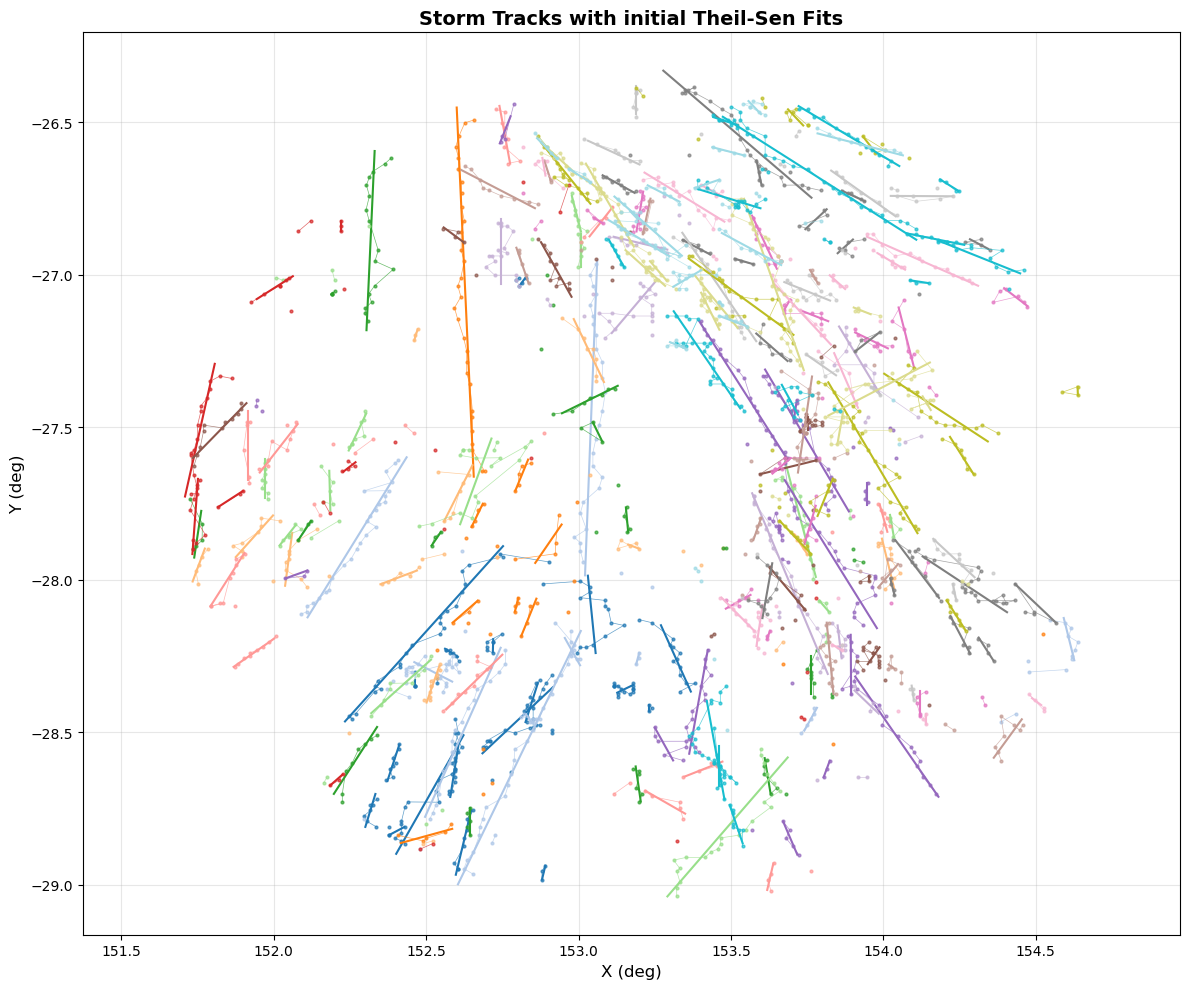

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245 24

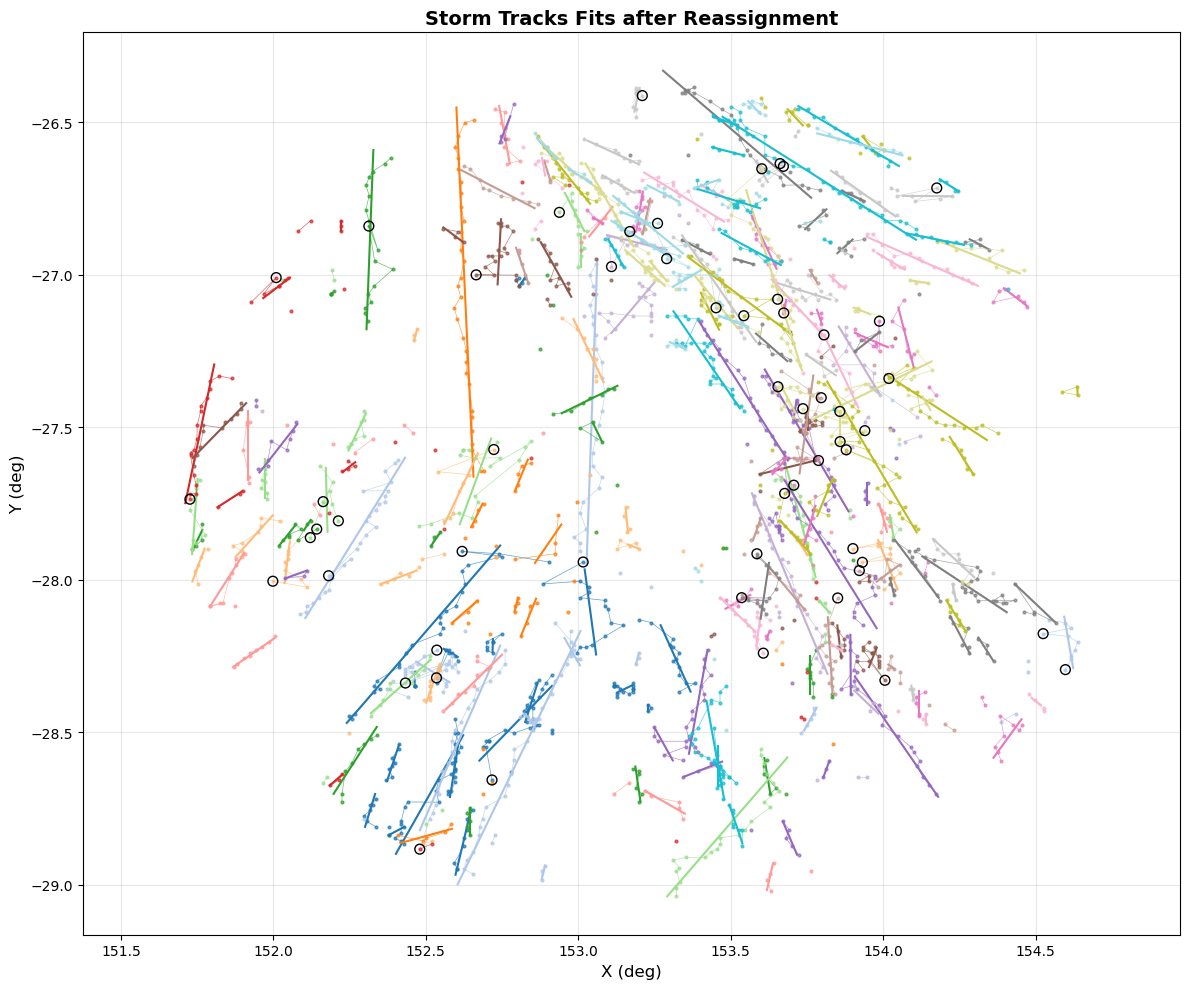


 0 iteration. Tracks merged: 51
[  0   1   2   3   4   7   6   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  26  27  28  29  30  31  32  34  39  40  36  37
  41  42  43  46  47  48  49  51  52  55  56  57  59  60  61  62  63  64
  65  66  67  68  69  72  71  73  74  75  76  78  79  80  81  82  83  84
  85  86  87  88  89  90  91  92  94  95  96  97  98  99 102 103 104 105
 106 101 107 108 109 111 112 113 114 119 120 118 127 124 125 126 128 129
 132 133 134 135 141 136 137 138 139 142 143 144 145 140 146 147 148 150
 151 152 153 154 155 156 157 158 159 161 162 163 164 160 166 167 168 169
 170 171 172 173 174 176 177 178 179 180 181 182 183 184 185 186 188 189
 190 191 192 193 194 195 196 197 198 199 200 201 203 205 206 207 208 209
 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227
 228 230 231 233 234 235 236 237 238 239 241 242 244 245 247 249 250 251
 252 253 254 255 256 257 258 259 260 261 262 263 264 267 268 269 270 271
 272 273 274 275 2

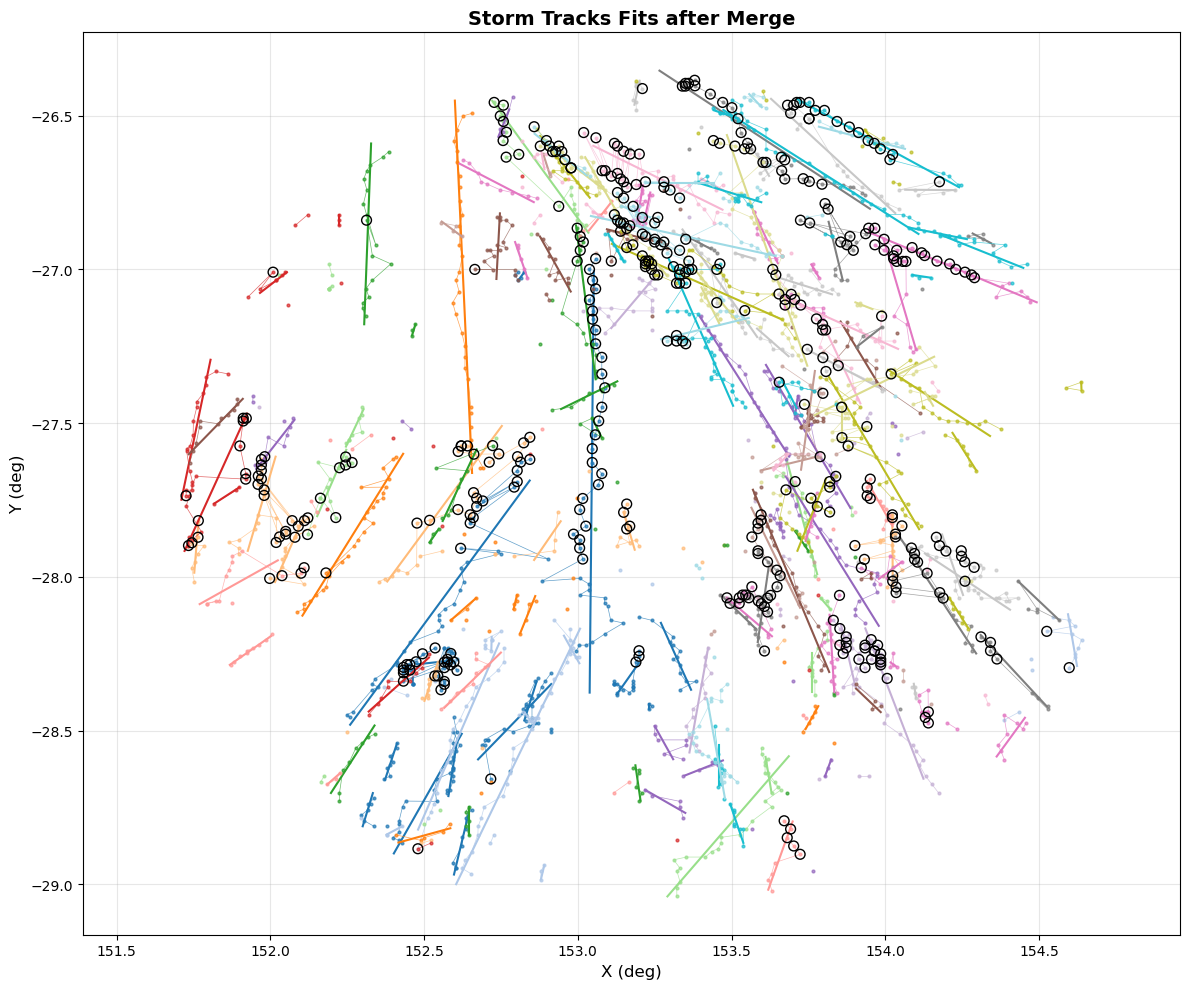


 0 iteration. Small tracks to be pruned: 192, Cells reassigned from small tracks before pruning: 11
[  1   2   3   7   6   8  10  11  12  13  14  15  17  18  19  20  22  23
  27  28  30  39  40  43  46  55  56  59  65  66  68  72  74  78  80  85
  87  88  89  90  91  92  97  98  99 102 105 107 109 111 113 114 127 125
 128 129 133 135 141 138 139 144 153 154 161 166 167 171 173 176 177 180
 183 184 186 188 190 191 194 195 196 197 200 201 203 213 222 223 224 225
 228 231 233 235 239 245 250 252 256 259 264 263 267 268 269 270 272 275
 277 278 279 280 281 282 283 284 288 290 294 307 308 309 310 311 312 314
 317 322 323 324 326 327 331 332 338 341 342 345 352 353 354 355 357 360
 361 365 370 373 374 377 378 382 384 385 386 392 393 398 399 400 406 411
 409 412 414 415 416 417 419 420 424 425 426 429 431 432 433 434 437 439
 440 442 447 453 455 457 461]


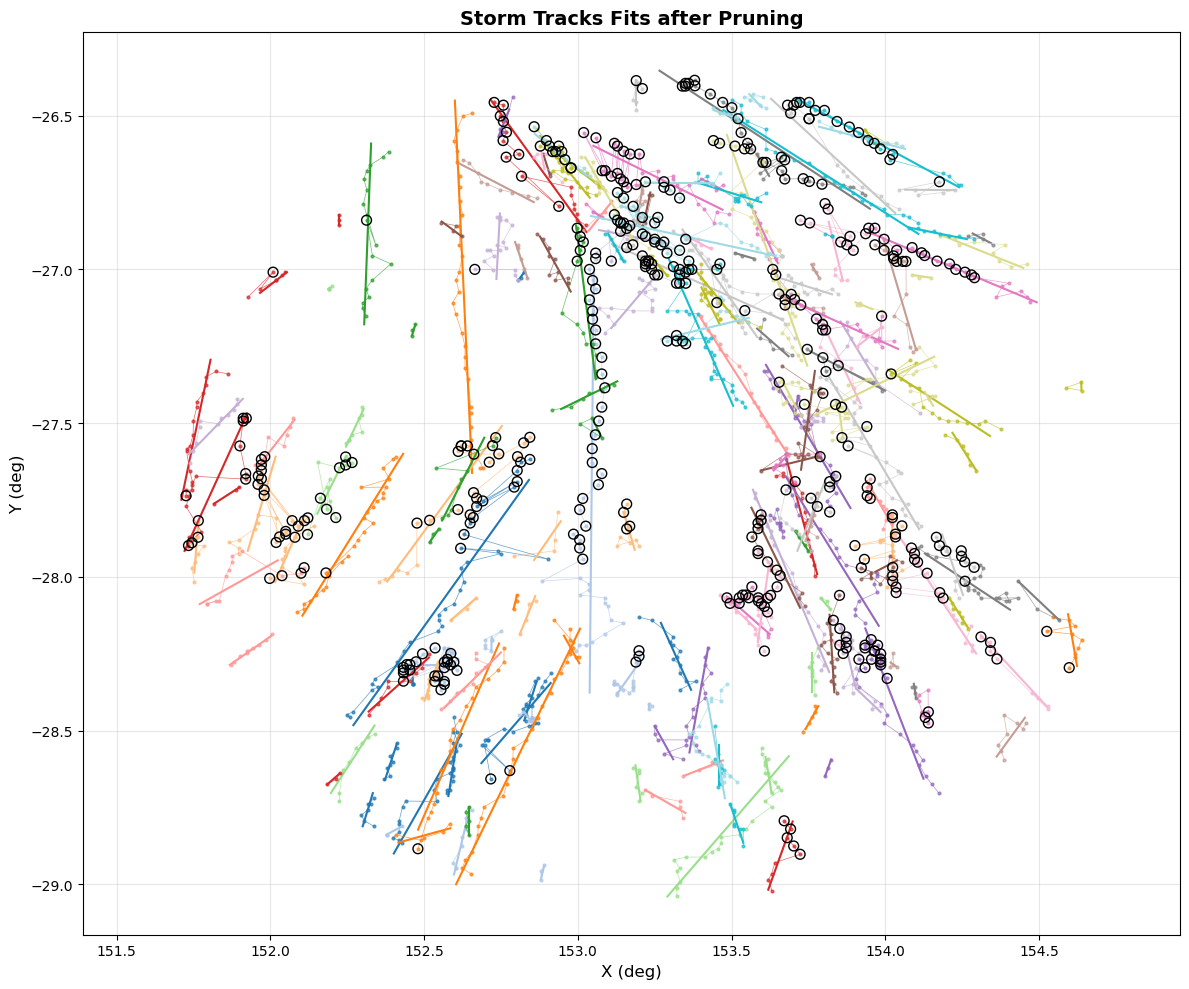


 0 iteration. Cells removed to enforce simple tracks: 71
[  1   2   3   7   6   8  10  11  12  13  14  15  17  18  19  20  22  23
  27  28  30  39  40  43  46  55  56  59  65  66  68  72  74  78  80  85
  87  88  89  90  91  92  97  98  99 102 105 107 109 111 113 114 127 125
 128 129 133 135 141 138 139 144 153 154 161 166 167 171 173 176 177 180
 183 184 186 188 190 191 194 195 196 197 200 201 203 213 222 223 224 225
 228 231 233 235 239 245 250 252 256 259 264 263 267 268 269 270 272 275
 277 278 279 280 281 282 283 284 288 290 294 307 308 309 310 311 312 314
 317 322 323 324 326 327 331 332 338 341 342 345 352 353 354 355 357 360
 361 365 370 373 374 377 378 382 384 385 386 392 393 398 399 400 406 411
 409 412 414 415 416 417 419 420 424 425 426 429 431 432 433 434 437 439
 440 442 447 453 455 457 461]


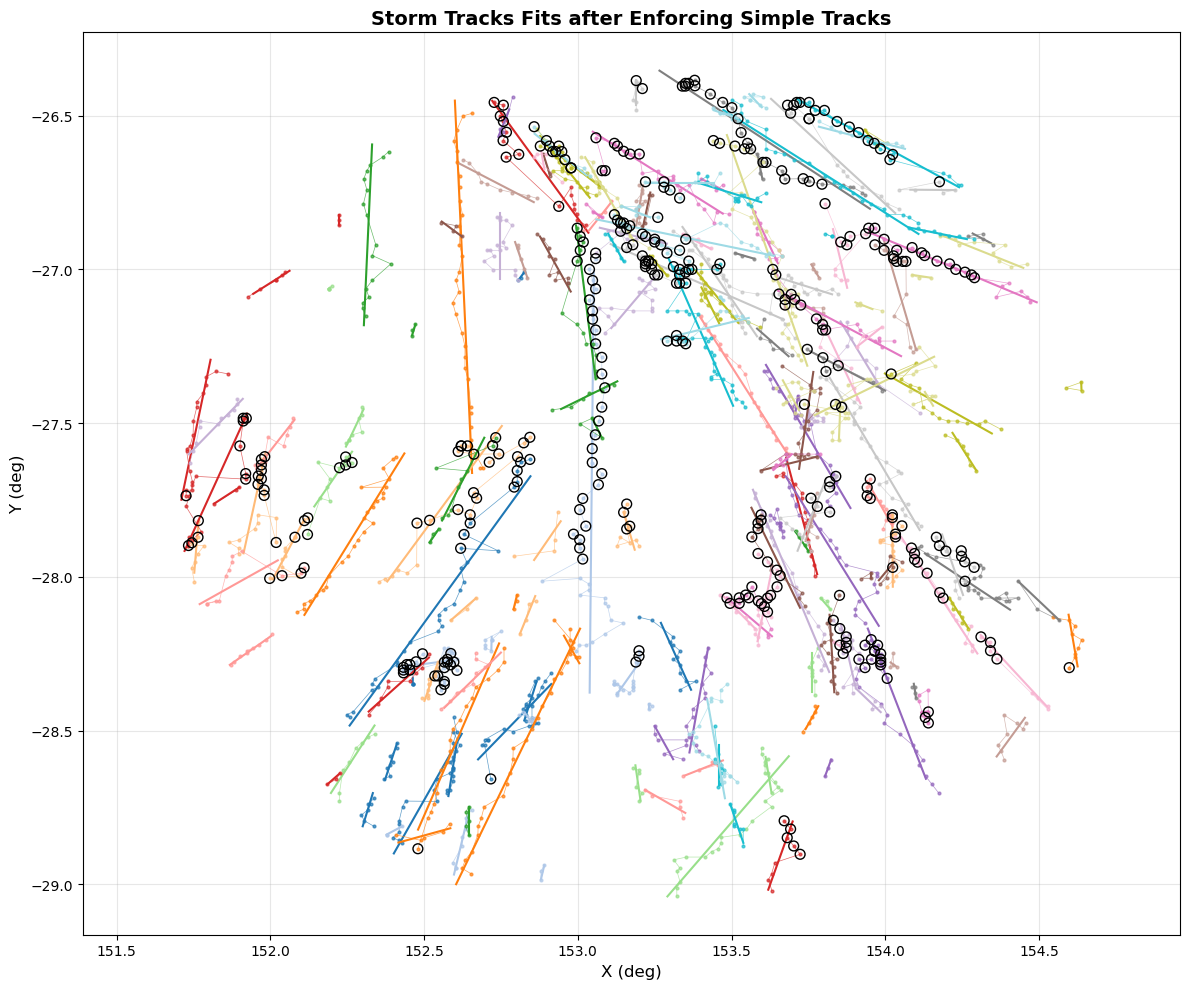

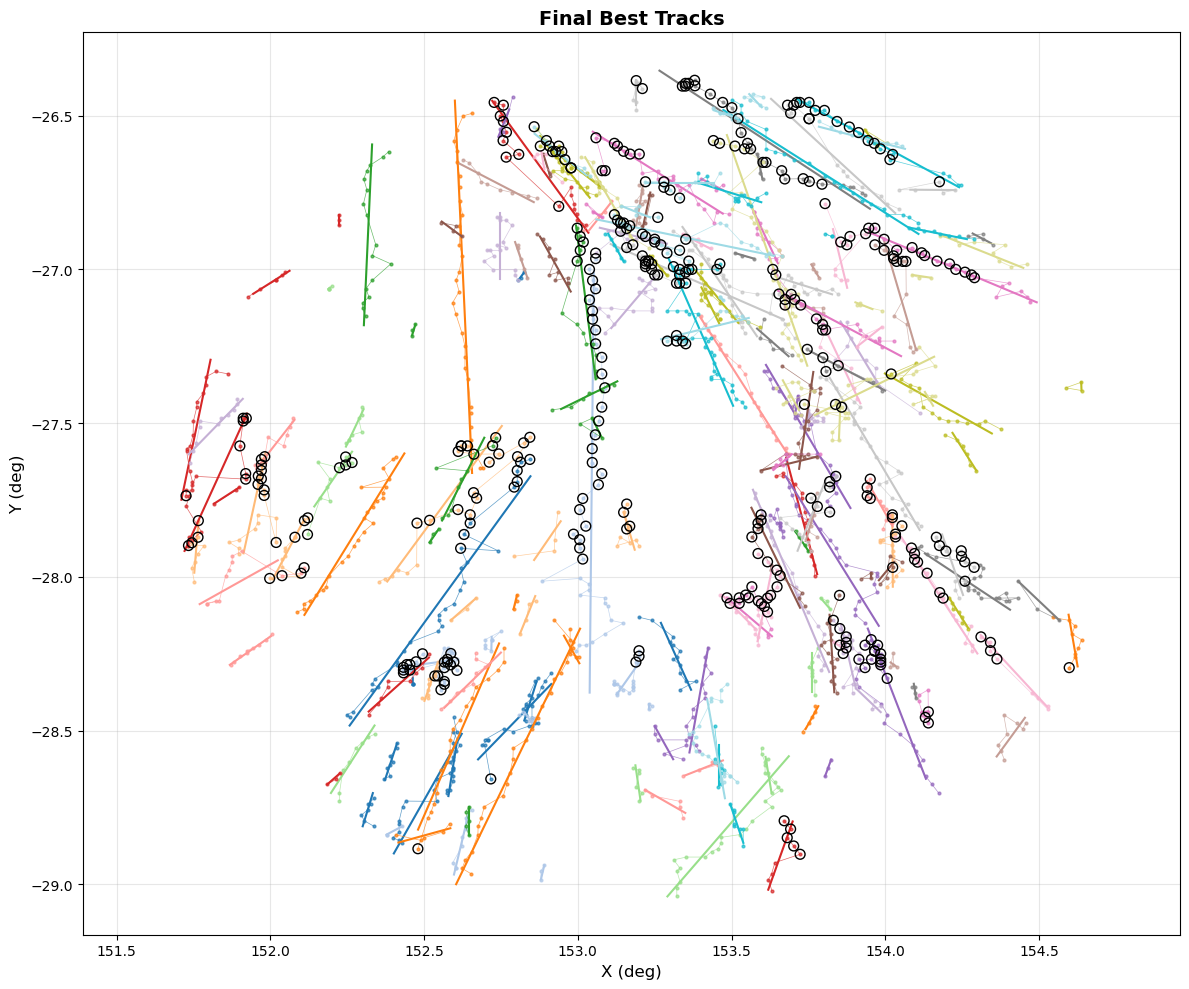

In [8]:
tracks_df = df.copy()
tracks_df = tracks_df.rename(columns={'time': 'timestamp', 'uid': 'track_id', 'weighted_center_x': 'x', 'weighted_center_y': 'y'})
tracks_df['timestamp'] = pd.to_datetime(tracks_df['timestamp'])
tracks_df['initial_track_id'] = tracks_df['track_id']
tracks_df['filter'] = None

# test_df = pd.DataFrame({
#     'track_id': [1, 1, 1, 2, 2, 2, 2, 3],
#     'timestamp': pd.to_datetime([
#         '2024-01-01 12:00:00',
#         '2024-01-01 12:05:00',
#         '2024-01-01 12:10:00',
#         '2024-01-01 12:15:00',
#         '2024-01-01 12:20:00',
#         '2024-01-01 12:25:00',
#         '2024-01-01 12:30:00',
#         '2024-01-01 12:35:00'
#     ]),
#     'x': [10.0, 12.0, 14.0, 15.0, 16.0, 17.0, 20.0, 22.0],
#     'y': [5.0, 6.0, 9.0, 10.0, 15.0, 15.0, 17.0, 19.0]
# })
# test_df['initial_track_id'] = test_df['track_id']

fits_df = calculate_theil_sen_parameters(tracks_df)
plot_track_fits(tracks_df, fits_df, track_ids=None, title='Storm Tracks with initial Theil-Sen Fits')
print(np.array(tracks_df['track_id'].unique()))

for i in range(5):

    # Pass 1: Reassign cells to nearest tracks
    tracks_pass1_df, pass1_n_reassigned = reassign_cells_to_nearest_tracks(tracks_df, fits_df, distance_threshold=0.1)
    fits_pass1_df = calculate_theil_sen_parameters(tracks_pass1_df)
    print(f"\n {i} iteration. Cells reassigned: {pass1_n_reassigned}")
    print(np.array(tracks_pass1_df['track_id'].unique()))
    plot_track_fits(tracks_pass1_df, fits_pass1_df, track_ids=None, title='Storm Tracks Fits after Reassignment')

    # Pass 2: Merge tracks based on proximity and time overlap
    tracks_pass2_df, merge_count = merge_tracks(tracks_pass1_df, fits_pass1_df, distance_threshold=0.2, time_overlap_threshold=960)
    fits_pass2_df = calculate_theil_sen_parameters(tracks_pass2_df)
    print(f"\n {i} iteration. Tracks merged: {merge_count}")
    print(np.array(tracks_pass2_df['track_id'].unique()))
    plot_track_fits(tracks_pass2_df, fits_pass2_df, track_ids=None, title='Storm Tracks Fits after Merge')

    #Pass 3: Prune tracks with fewer than 3 cells and reassign their cells to nearest tracks
    tracks_pass3_df, pruned_count, reassigned_from_pruned = prune_tracks(tracks_pass2_df, fits_pass2_df, distance_threshold=0.1, min_cells=3)
    fits_pass3_df = calculate_theil_sen_parameters(tracks_pass3_df)
    print(f"\n {i} iteration. Small tracks to be pruned: {pruned_count}, Cells reassigned from small tracks before pruning: {reassigned_from_pruned}")
    print(np.array(tracks_pass3_df['track_id'].unique()))
    plot_track_fits(tracks_pass3_df, fits_pass3_df, track_ids=None, title='Storm Tracks Fits after Pruning')

    #Pass 4: Remove duplicate timesteps
    tracks_pass4_df, tie_breaks = enforce_simple_track(tracks_pass3_df, fits_pass3_df)
    fits_pass4_df = calculate_theil_sen_parameters(tracks_pass4_df)
    print(f"\n {i} iteration. Cells removed to enforce simple tracks: {tie_breaks}")
    print(np.array(tracks_pass4_df['track_id'].unique()))
    plot_track_fits(tracks_pass4_df, fits_pass4_df, track_ids=None, title='Storm Tracks Fits after Enforcing Simple Tracks')
    
    tracks_df = tracks_pass4_df
    fits_df = fits_pass4_df
    break
plot_track_fits(tracks_df, fits_df, track_ids=None, title='Final Best Tracks')
